# 평가

### 머신러닝의 과정: 데이터 가공/변환->모델 학습/예측->평가

### 분류 관련 평가지표: 정확도(Accuracy,오차행렬(Confusion Matrix),정밀도(Precision),재현율(Recall),F1 스코어,ROC AUC
#### 이진 분류: 긍정/부정과 같이 2개의 결과값만을 가지는 이진 분류
#### 멀티분류: 여러 개의 결정 클래스를 가짐

## 정확도(Accuracy)
### :정확도는 실제 데이터에서 예측 데이터가 얼마나 같은지 평가하는 지표-직관적으로 모델 예측 성능 표현
### ->주의점: 이진 분류의 경우 데이터 구성에 따라 ML 모델의 성능 왜곡 가능
### 정확도(Accuracy)=예측 결과가 동일한 데이터 건수/전체 예측 데이터 건수

In [2]:
from sklearn.base import BaseEstimator
class MyDummyClassifier(BaseEstimator):
    #fit() 매서드는 아무것도 학습하지 않음
    def fit(self,X,y=None):
        pass
    #predict()매서드는 단순히 Sex 피처가 1이면 0 그렇지 않으면 1로 예측함
    def predict(self,X):
        pred=np.zeros((X.shape[0],1))
        for i in range(X.shape[0]):
            if X['Sex'].iloc[i]==1:
                pred[i]=0
            else:
                pred[i]=1
        return pred

In [3]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
def fillna(df):
    df['Age'].fillna(df['Age'].mean(),inplace=True)
    df['Cabin'].fillna('N',inplace=True)
    df['Embarked'].fillna('N',inplace=True)
    return df
def drop_features(df):
    df.drop(['Name','Ticket'],axis=1,inplace=True)
    return df
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features=['Cabin','Sex','Embarked']
    for feature in features:
        le=LabelEncoder()
        le=le.fit(df[feature])
        df[feature]=le.transform(df[feature])
    return df
def transform_features(df):
    df=fillna(df)
    df=drop_features(df)
    df=format_features(df)
    return df

#### 생성된 MyDummyClassifier를 통해 생존자 예측 수행

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할
titanic_df=pd.read_csv('train.csv')
y_titanic_df=titanic_df['Survived']
X_titanic_df=titanic_df.drop('Survived',axis=1)
x_titanic_df=transform_features(X_titanic_df)
X_train,X_test,y_train,y_test=train_test_split(X_titanic_df,y_titanic_df,test_size=0.2,random_state=0)
#위에서 생성한 Dummy Classifier을 이용해 학습/예측 수행
myclf=MyDummyClassifier()
myclf.fit(X_train,y_train)
mypredictions=myclf.predict(X_test)
print('Dummy Classifierdml 정확도는: {0:.4f}'.format(accuracy_score(y_test,mypredictions)))

Dummy Classifierdml 정확도는: 0.7877


/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1357/1977711444.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1357/1977711444.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

### 문제점: 단순 알고리즘 예측을 해도 데이터에 따라 정확도 결과가 높을 수 있다. 정확도는 불균형한 레이블 분포에서 ML 모델 평가시에 적합하지 않다.

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
class MyFakeClassifier(BaseEstimator):
    def fit(self, X, y):
        pass
    # 입력값으로 들어오는 X 데이터 세트의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)
# 사이킷런의 내장 데이터 세트인 load_digits()를 이용해 MNIST 데이터 로딩
digits = load_digits()
# digits 번호가 7번이면 True이고 이를 astype(int)로 1로 변환, 7번이 아니면 False이고 0으로 변환
y = (digits.target == 7).astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, y, random_state=11
)

#### 불균형한 데이터로 생성한 y_test의 데이터 분포도 확인하고 MyFakeClassifier로 예측과 평가 수행

In [6]:
#불균형한 레이블 데이터 분포도 확인
print('레이블 테스트 세트 크기:',y_test.shape)
print('테스트 세트 레이블 0과 1의 분포도')
print(pd.Series(y_test).value_counts())
#Dummy Classifier로 학습/예측/정확도 평가
fakeclf=MyFakeClassifier()
fakeclf.fit(X_train,y_train)
fakepred=fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는:{:.3f}'.format(accuracy_score(y_test,fakepred)))

레이블 테스트 세트 크기: (450,)
테스트 세트 레이블 0과 1의 분포도
0    405
1     45
Name: count, dtype: int64
모든 예측을 0으로 하여도 정확도는:0.900


#### 단순히 predict()결과를 np.zeros로 변환했음에도 정확도가 90%다 -> 즉 정확도 평가 지표는 불균형한 레이블 데이터 세트에서 성능 지표로 사용될 수 없다.

## 오차행렬
### :이진 분류의 예측 오류가 얼마인지와 더불어 어떻나 예측 오류가 발생하고 있는지 함께 나타내는 지표이다.
### 오차행렬은 4분면 안에서 실제 레이블 클래스 값과 예측 레이블 값이 어떤 유형 가지고 맵핑이 되는지 나타낸다.

#### -TN:예측값을 Negative 0으로 예측했고 실제값도 Negative 값 0
#### -FP:예측값을 Positive 값 1로 예측했는데 실지값은 Negative 값 0
#### -FN은 예측값을 Negative값 0으로 예측했는데 실제 값은 positive 값 1  
#### -TP는 예측 값을 Positive 1로 예측 했는데 실제 값 역시 Postive 값 1

#### ->이를 통해 어떠한 모습으로 예측 성능 오류가 나타나는지 파악이 가능하다.


## 사이킷런 제공 API: confusion_matrix()

In [7]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,fakepred)

array([[405,   0],
       [ 45,   0]])

#### ->이를 통해 각 4분면에 따른 예측 성능 오류를 알 수 있다.
#### 이 값들을 조합해 정확도, 재현율, 정밀도를 알 수 있다

### 정확도=예측 결과와 실제 값이 동일한 건수/전체 데이터 수=(TN+TP)/(TN+FP+FN+TP)

## 정밀도와 재현율

### 정밀도=TP/(FP+TP)
### 재현율=TP/(FN+TP)

### 정밀도(=양성 예측도):Positive 예측 성능을 더욱 정밀하게 측정하기 위한 평가지표
### 재현율(=민감도 or TPR): 실제값이 positive 대상 중에 예측과 실제 값이 모두 positive로 일치한 데이터의 비율
#### ->상황에 따라 재현율이 더 중요하거나 정밀도가 더 중요해지기도 함
#### 재현율이 중요 지표인 경우: 실제 Positive 야성 데이터를 Negative로 잘못 판단하게 되면 업무상 큰 영향이 발생하는 경우(FN 낮추는데 중점)

#### 정밀도가 중요 지표인 경우: 실제 Negative 음성인 데이터 예측을 Postive 양성으 잘못 판단하게 되면 업무상 큰 영향이 발생 경우(FP 낮추는데 중점)

### 사이킷런 제공: recall_score()(재현율 계산),precision_scrore(정밀도 계산)

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)

    print("오차 행렬")
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

In [9]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 원본 데이터를 재로딩, 데이터 가공, 학습 데이터/테스트 데이터 분할
titanic_df = pd.read_csv('train.csv')

y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

X_train, X_test, y_train, y_test = train_test_split(
    X_titanic_df, y_titanic_df,
    test_size=0.20, random_state=11
)

lr_clf = LogisticRegression(solver='liblinear')
lr_clf.fit(X_train, y_train)
pred=lr_clf.predict(X_test)
get_clf_eval(y_test,pred)

오차 행렬
[[107  11]
 [ 14  47]]
정확도: 0.8603, 정밀도: 0.8103, 재현율: 0.7705


/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1357/1977711444.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)
/var/folders/lw/typ49f210hb_6wlv9djt899c0000gn/T/ipykernel_1357/1977711444.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

## 정밀도/재현율 트레이드 오프
#### 정밀도나 재현율이 특별히 강조되야 할 때 분류의 임곗값(Threshold)을 조정해 정밀도나 재현율 높일 수 있다.
#### ->그러나 정밀도와 재현율은 상호보완적 평가지표여서 한 쪽을 높이면 다른 한쪽이 낮아져 정밀도/재현율(Trade-off라고 부름

#### 사이킷런 분류 알고리즘은 개별 레이블별 결정 확률 구하고 예측 확률이 큰 레이블 값으로 예측
#### 관련 매서드: predict_proba()(예측ㄱ률 반환 매서드)-predict와 유사하지만 예특 결과가 아닌 예측 확률을 반환

In [10]:
pred_proba = lr_clf.predict_proba(X_test)
pred = lr_clf.predict(X_test)

print('pred_proba() 결과 Shape : {0}'.format(pred_proba.shape))
print('pred_proba array에서 앞 3개만 샘플로 추출 \n:', pred_proba[:3])

# 예측 확률 array와 예측 결과값 array를 병합(concatenate)해 예측 확률과 결과값을 한눈에 확인
pred_proba_result = np.concatenate([pred_proba, pred.reshape(-1, 1)], axis=1)
print('두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 \n', pred_proba_result[:3])

pred_proba() 결과 Shape : (179, 2)
pred_proba array에서 앞 3개만 샘플로 추출 
: [[0.4471007  0.5528993 ]
 [0.85021561 0.14978439]
 [0.85833879 0.14166121]]
두 개의 class 중에서 더 큰 확률을 클래스 값으로 예측 
 [[0.4471007  0.5528993  1.        ]
 [0.85021561 0.14978439 0.        ]
 [0.85833879 0.14166121 0.        ]]


#### 반환 결과인 ndarray는 0과 1에 대한 확률 나타내 1이 되고 마지막 줄에서 두 개의 칼럼 중 더 큰 확률 값으로 predict()가 예측

### 사이킷런의 분류 결정 임곗값을 조절해 정밀도와 재현율의 성능 수치 상호보완을 해보기(정밀도/재현율 트레이드오프 이해)

In [11]:
from sklearn.preprocessing import Binarizer

X = [[1, -1, 2],
     [2, 0, 0],
     [0, 1.1, 1.2]]

# X의 개별 원소들이 threshold값보다 같거나 작으면 0을, 크면 1을 반환
binarizer = Binarizer(threshold=1.1)
print(binarizer.fit_transform(X))

[[0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]]


#### 이제 구한 최종 예측 값에 대한 get_clf_eval()함수로 평가 지표 출력

In [12]:
from sklearn.preprocessing import Binarizer

# Binarizer의 threshold 설정값. 분류 결정 임계값임.
custom_threshold = 0.5

# predict_proba() 반환값의 두 번째 칼럼, 즉 Positive 클래스 칼럼 하나만 추출해 Binarizer를 적용
pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[107  11]
 [ 14  47]]
정확도: 0.8603, 정밀도: 0.8103, 재현율: 0.7705


#### 이를 통해 계산된 평가지표는 앞에서의 로지스틱 회귀 객체에서 호출된 predict() 계산 지표값과 같고 predict()가 predict_proba()에 기반한 것을 알 수 있다.

In [13]:
# Binarizer의 threshold 설정값을 0.4로 설정, 즉 분류 결정 임계값을 0.5에서 0.4로 낮춤
custom_threshold = 0.4

pred_proba_1 = pred_proba[:, 1].reshape(-1, 1)

binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_1)
custom_predict = binarizer.transform(pred_proba_1)

get_clf_eval(y_test, custom_predict)

오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197


### 임계값이 낮아지니 재현율이 높아지고 정밀도가 떨어졌다.
#### positive 예측값이 많아지면 상대적으로 재현율 값이 높아진다(양성 예측이 늘어나 음성 예측이 줄어들기 때문)

In [14]:
#테스트를 수행할 모든 임곗값을 리스트 객체로 저장
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def get_eval_by_threshold(y_test, pred_proba_c1, thresholds):
    # thresholds list객체 내의 값을 차례로 iteration 하면서 evaluation 수행
    for custom_threshold in thresholds:
        binarizer = Binarizer(threshold=custom_threshold).fit(pred_proba_c1)
        custom_predict = binarizer.transform(pred_proba_c1)
        print('임곗값:', custom_threshold)
        get_clf_eval(y_test, custom_predict)
get_eval_by_threshold(y_test, pred_proba[:,1].reshape(-1,1),thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197
임곗값: 0.45
오차 행렬
[[102  16]
 [ 14  47]]
정확도: 0.8324, 정밀도: 0.7460, 재현율: 0.7705
임곗값: 0.5
오차 행렬
[[107  11]
 [ 14  47]]
정확도: 0.8603, 정밀도: 0.8103, 재현율: 0.7705
임곗값: 0.55
오차 행렬
[[111   7]
 [ 15  46]]
정확도: 0.8771, 정밀도: 0.8679, 재현율: 0.7541
임곗값: 0.6
오차 행렬
[[114   4]
 [ 17  44]]
정확도: 0.8827, 정밀도: 0.9167, 재현율: 0.7213


#### 반환된 임계값 데이터 147건 중 샘플로 10개만 추출해 15단계로 추출해 더 큰 값의 임곗값과 그때의 정밀도와 재현율 값 확인

In [15]:
from sklearn.metrics import precision_recall_curve

# 레이블 값이 1일 때의 예측 확률 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

# 실제값 데이터 세트와 레이블 값이 1일 때의 예측 확률을 precision_recall_curve 인자로 입력
precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_class1)
print('반환된 분류 결정 임곗값 배열의 Shape:', thresholds.shape)

# 반환된 임계값 배열 로우가 147건이므로 샘플로 10건만 추출하되, 임곗값을 15step으로 추출
thr_index = np.arange(0, thresholds.shape[0], 15)
print('샘플 추출을 위한 임곗값 배열의 index 10개:', thr_index)
print('샘플용 10개의 임곗값:', np.round(thresholds[thr_index], 2))

# 15 step단위로 추출된 임계값에 따른 정밀도와 재현율 값
print('샘플 임곗값별 정밀도:', np.round(precisions[thr_index], 3))
print('샘플 임곗값별 재현율:', np.round(recalls[thr_index], 3))

반환된 분류 결정 임곗값 배열의 Shape: (179,)
샘플 추출을 위한 임곗값 배열의 index 10개: [  0  15  30  45  60  75  90 105 120 135 150 165]
샘플용 10개의 임곗값: [0.02 0.11 0.13 0.14 0.15 0.19 0.27 0.39 0.5  0.63 0.75 0.89]
샘플 임곗값별 정밀도: [0.341 0.372 0.396 0.433 0.462 0.529 0.618 0.689 0.797 0.932 0.966 1.   ]
샘플 임곗값별 재현율: [1.    1.    0.967 0.951 0.902 0.902 0.902 0.836 0.77  0.672 0.459 0.23 ]


#### 추출된 임곗값 샘플 10개에 해당하는 정밀도와 재현율을 살펴보면 임계값이 증가할 수록 정밀도는 높아지나 재현율이 낮아지는 것을 확인 가능

### 사이킷런 API: precision_recall_curve()-정밀도와 재현율을 임계값에 따른 값 변화를 곡선 형태의 그래프로 시각화 가능

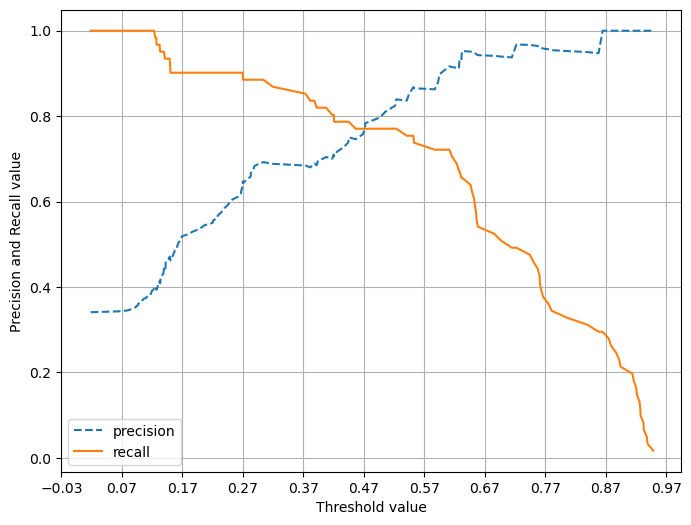

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline
def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 threshold에 따른 정밀도, 재현율 ndarray 추출
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    # X축을 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행
    plt.figure(figsize=(8, 6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary],linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary],label='recall')

    # threshold 값 X축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))

    # X축, Y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value')
    plt.ylabel('Precision and Recall value')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall_curve_plot(y_test,lr_clf.predict_proba(X_test)[:, 1])

#### 정밀도는 점선으로 재현율은 실선 표현->임곗값이 낮을수록 많은 수의 양성 예측으로 재현율 값 높아지고 정밀도 값이 극도록 낮아짐
#### 임곗값이 증가할 수록 재현율은 낮아지고 정밀도 값은 높아짐

## 정밀도와 재현율의 맹점
### ->임계값의 변경은 업무환경에 맞게 두개의 수치 상호 보완 수준에서 사용되어야 하지 특정 지표 수치 높이기 위해 사용해서는 안된다.
### 정밀도가 100%되는 법:확실한 기준이 되는 경우만 positive 나머지 다 Negative 예측
### 재현율 100%가 되는 법: 모든 환자를 positive로 예측

## F1 스코어 -정밀도와 재현율이 어느 한쪽으로 치우치지 않는 수치를 나타낼 때 상대적으로 높은 값을 가짐

In [18]:
from sklearn.metrics import f1_score
f1=f1_score(y_test,pred)
print('F1 스코어: {0:.4f}'.format(f1))

F1 스코어: 0.7899


#### 타이타닉 생존자 예측에서 임계값 변화시키면서 F1 스코어 포함 평가지표 구해보기

In [19]:
def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    # F1 스코어 추가
    f1 = f1_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    #f1 score print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1:{3:.4f}'.format(accuracy, precision, recall, f1))
thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]
pred_proba = lr_clf.predict_proba(X_test)
get_eval_by_threshold(y_test,pred_proba[:,1].reshape(-1,1),thresholds)

임곗값: 0.4
오차 행렬
[[97 21]
 [11 50]]
정확도: 0.8212, 정밀도: 0.7042, 재현율: 0.8197, F1:0.7576
임곗값: 0.45
오차 행렬
[[102  16]
 [ 14  47]]
정확도: 0.8324, 정밀도: 0.7460, 재현율: 0.7705, F1:0.7581
임곗값: 0.5
오차 행렬
[[107  11]
 [ 14  47]]
정확도: 0.8603, 정밀도: 0.8103, 재현율: 0.7705, F1:0.7899
임곗값: 0.55
오차 행렬
[[111   7]
 [ 15  46]]
정확도: 0.8771, 정밀도: 0.8679, 재현율: 0.7541, F1:0.8070
임곗값: 0.6
오차 행렬
[[114   4]
 [ 17  44]]
정확도: 0.8827, 정밀도: 0.9167, 재현율: 0.7213, F1:0.8073


## ROC 곡선과 AUC
### ROC 곡선과 AUC 스코어는 이진 분류에서 예측 성능 측정에 중요하게 사용이 된다.
### ROC 곡선(수신자 판단 곡선):FPR이 변할 때 TPR이 어떻게 변화하는지 나타내는 곡선
### 민감도(TPR)-실제값 positive가 정확히 예측되야 하는 수준을 나타냄
### 특이성(TNR)-실제값 negative(음성)이 정확하게 예측돼야 하는 수준 나타냄

### FPR=FP/(FP+TN)=1-TNR=1-특성

### roc_curve() API 활용 FPR,TPR,임곗값 구하기

In [21]:
import numpy as np
from sklearn.metrics import roc_curve

# 레이블 값이 1일때의 예측 확률을 추출
pred_proba_class1 = lr_clf.predict_proba(X_test)[:, 1]

fprs, tprs, thresholds = roc_curve(y_test, pred_proba_class1)

# 반환된 임곗값 배열에서 샘플로 데이터를 추출하되, 임곗값을 5 Step으로 추출.
# thresholds[0]은 max(예측확률)+1로 임의 설정됨. 이를 제외하기 위해 np.arange는 1부터 시작
thr_index = np.arange(1, thresholds.shape[0], 5)

print('샘플 추출을 위한 임곗값 배열의 index:', thr_index)
print('샘플 index로 추출한 임곗값:', np.round(thresholds[thr_index], 2))

# 5 step 단위로 추출된 임곗값에 따른 FPR, TPR 값
print('샘플 임곗값별 FPR:', np.round(fprs[thr_index], 3))
print('샘플 임곗값별 TPR:', np.round(tprs[thr_index], 3))

샘플 추출을 위한 임곗값 배열의 index: [ 1  6 11 16 21 26 31 36]
샘플 index로 추출한 임곗값: [0.95 0.63 0.59 0.45 0.39 0.27 0.13 0.12]
샘플 임곗값별 FPR: [0.    0.017 0.059 0.136 0.195 0.254 0.712 0.788]
샘플 임곗값별 TPR: [0.016 0.656 0.721 0.787 0.82  0.902 0.951 1.   ]


#### roc_curve값을 보면 임곗값이 1에 가까운 값에서 점점 작아지면서 FPR 값이 커진다.FPR 값이 조금씩 커질때 TPR 값은 가파르게 커진다.

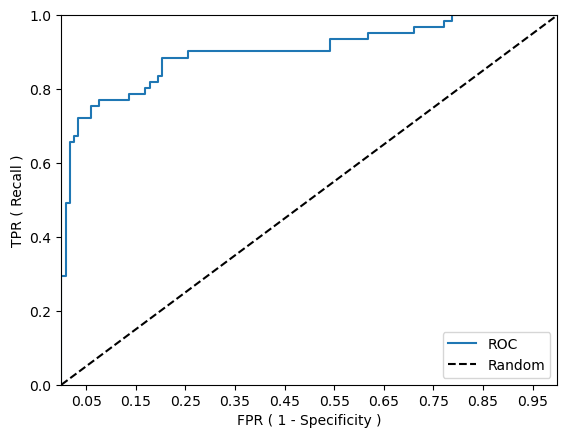

In [22]:
def roc_curve_plot(y_test, pred_proba_c1):
    # 임곗값에 따른 FPR, TPR 값을 반환받음.
    fprs, tprs, thresholds = roc_curve(y_test, pred_proba_c1)
    # ROC 곡선을 그래프 곡선으로 그림.
    plt.plot(fprs, tprs, label='ROC')
    # 가운데 대각선 직선을 그림.
    plt.plot([0, 1], [0, 1], 'k--', label='Random')

    # FPR X 축의 Scale을 0.1 단위로 변경, X, Y축 명 설정 등
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1), 2))
    plt.xlim(0, 1);plt.ylim(0, 1)
    plt.xlabel('FPR ( 1 - Specificity )');plt.ylabel('TPR ( Recall )')
    plt.legend()
roc_curve_plot(y_test,pred_proba[:,1])

#### ROC 곡선 자체는 FPR과 TPR 변화 값을 보기 좋고 AUC는 ROC 곡선의 밑 면적을 구한 값으로 1에 가까울 수록 좋다.
#### AUC 수치가 커지려면 FPR이 작은 상태에서 얼마나 큰 TPR을얻을 수 있는냐가 관건

In [23]:
from sklearn.metrics import roc_auc_score
pred_proba = lr_clf.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, pred_proba)
print('ROC AUC 값: {0:.4f}'.format(roc_score))

ROC AUC 값: 0.8998


In [24]:
def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    #ROC_AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, \
F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))